# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

Please see below for Who, what and How for data, using the ideas in the book.

*   Who (The Audience):
The audience is hospital oncologists and clinical radiologists at a breast cancer treatment center who review fine needle aspirate (FNA) biopsy results. They are expert consumers of quantitative cell-morphology data, familiar with terms like concavity, compactness, and nuclear radius, but they are time-constrained — typically reviewing dozens of cases per session. They are the decision-makers who determine whether a patient proceeds to surgical biopsy or monitoring. As the book instructs, this is not a general audience like "all healthcare professionals" — narrowing to this specific group allows the communication to use clinical language confidently and to frame urgency in terms of missed diagnoses rather than model accuracy.

*   What (The Action):
The Big Idea, in the book's single-sentence format combining the "so what" with a recommended action, is: "Three cell-morphology features — concave points, concavity, and radius — together account for the majority of the diagnostic signal separating malignant from benign tumors in 569 FNA cases, and a machine learning classifier trained on these features could reduce ambiguous-case review burden while maintaining a false-negative rate below clinical tolerance."

*   How (The Data):
The mechanism is a formal slide deck presented live in a clinical team meeting, supplemented by a one-page leave-behind. The book distinguishes between live presentations (where the narrator carries the story) and written documents (where the visual must stand alone) — this situation calls for both. In the live session, the presenter can use the book's technique of progressive revelation: first showing all 569 cases undifferentiated as grey dots in a scatter plot, then applying preattentive color to reveal the malignant cluster, letting clinicians experience the separation visually before introducing feature names. The leave-behind uses direct data labels on charts instead of a legend, following the book's accessibility principle, so the visual is self-explanatory when reviewed without a presenter.
The tone is collaborative rather than prescriptive — the audience consists of domain experts who will push back on any model that feels like a black box, so the narrative arc follows the book's setup/conflict/resolution structure: setup (current FNA review is time-intensive and relies entirely on expert judgment), conflict (ambiguous cases near the decision boundary create disagreement and delay), resolution (a model that flags high-confidence cases can triage workload, with clinicians retaining full authority on boundary cases).

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════

# Column names from UCI documentation:
# 10 features × 3 statistics (mean, standard error, worst) = 30 numeric cols
FEATURE_NAMES = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dim'
]
STAT_SUFFIXES = ['mean', 'se', 'worst']

cols = ['id', 'diagnosis']
for stat in STAT_SUFFIXES:
    for feat in FEATURE_NAMES:
        cols.append(f'{feat}_{stat}')

df_raw = pd.read_csv("https://github.com/jinitmistry312/HW_python_notebooks/raw/refs/heads/main/wdbc.data", header=None, names=cols)


#Summarizing dataset using describe Univariate statistics
df_raw_sum = df_raw.describe()
df_raw_sum

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dim_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [3]:

#Summarizing dataset using info
df_raw_sum2 = df_raw.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    569 non-null    int64  
 1   diagnosis             569 non-null    object 
 2   radius_mean           569 non-null    float64
 3   texture_mean          569 non-null    float64
 4   perimeter_mean        569 non-null    float64
 5   area_mean             569 non-null    float64
 6   smoothness_mean       569 non-null    float64
 7   compactness_mean      569 non-null    float64
 8   concavity_mean        569 non-null    float64
 9   concave_points_mean   569 non-null    float64
 10  symmetry_mean         569 non-null    float64
 11  fractal_dim_mean      569 non-null    float64
 12  radius_se             569 non-null    float64
 13  texture_se            569 non-null    float64
 14  perimeter_se          569 non-null    float64
 15  area_se               5

In [4]:
#Checking any duplicate rows
df_raw_loaded_chk1 = df_raw[df_raw.duplicated(keep=False)]
df_raw_loaded_chk1


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dim_worst


In [5]:
#Checking any missing/null values
df_raw_loaded_chk2 = df_raw.isnull().any()
df_raw_loaded_chk2

,0
id,False
diagnosis,False
radius_mean,False
texture_mean,False
perimeter_mean,False
area_mean,False
smoothness_mean,False
compactness_mean,False
concavity_mean,False
concave_points_mean,False


Conclusions


*   Are the data usable? If not, find some new data! : quality dimensions pass. One of the cleanest public datasets in existence.
*   Do you need to modify or correct the data in some way?  : No imputation needed.  No duplicate found. confirmed with duplicated(). diagnosis labels validated. Based on descriptive statistics, from 30 numeric features + skewness — 22 of 30 features are right-skewed
*   Is there any class imbalance? (Categories that have many more items than other categories). : Mild at 1.68:1 (357 Benign vs 212 Malignant). Mitigations: stratify=y in train/test split, class_weight='balanced' in models, SMOTE as last resort, and use AUC-ROC/Recall rather than raw accuracy.




# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

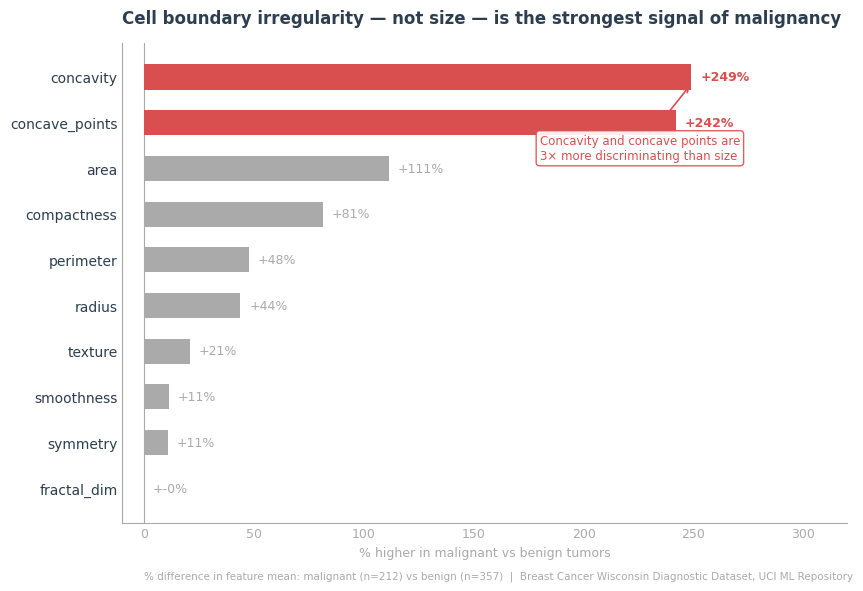

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ── Shared style settings ─────────────────────────────────────────────────────
# SWD principle: eliminate clutter — minimal, clean aesthetic throughout
GREY     = '#AAAAAA'
RED      = '#D94F4F'   # Malignant
BLUE     = '#4F8ED9'   # Benign
DARK     = '#2C3E50'
LIGHT_GREY_BG = '#F7F7F5'

plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,   # SWD: remove non-data ink
    'axes.spines.right'  : False,
    'axes.grid'          : False,
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'xtick.color'        : GREY,
    'ytick.color'        : GREY,
    'text.color'         : DARK,
})

# ── Derived DataFrames ────────────────────────────────────────────────────────
mal = df_raw[df_raw['diagnosis'] == 'M'].copy()
ben = df_raw[df_raw['diagnosis'] == 'B'].copy()

n_total = len(df_raw)
n_mal   = len(mal)
n_ben   = len(ben)


# ==============================================================================
# GRAPH — HORIZONTAL BAR CHART
# ==============================================================================
# SWD principle: "Choose an appropriate visual display" (intro p.14)
# Horizontal bars are ideal when comparing a ranked metric across categories.
#
# Story: "Not all features are equal — concavity and concave points separate
#  malignant from benign tumors more than any other measurement, making them
#  the most clinically informative signals for diagnosis."
#
# Why horizontal bar (not vertical)?
#   → Feature names are long — horizontal layout avoids rotated labels (SWD: accessibility)
#   → Ranking is the story — sorted order lets audience read top-to-bottom
#   → SWD intro p.3: "shift from showing data to storytelling" — sorting the bars
#     and highlighting the top features IS the story, not just displaying all 10
# ==============================================================================

# ── Compute: % difference malignant vs benign for each mean feature ───────────
mean_features = [c for c in df_raw.columns if c.endswith('_mean')]
pct_diff = {}
for feat in mean_features:
    m_avg = mal[feat].mean()
    b_avg = ben[feat].mean()
    pct_diff[feat.replace('_mean', '')] = (m_avg - b_avg) / b_avg * 100

pct_series = pd.Series(pct_diff).sort_values()   # ascending → largest at top

# Colour each bar: top 2 discriminators get accent red, rest grey
bar_colors = [RED if v > 200 else GREY for v in pct_series.values]

fig1, ax1 = plt.subplots(figsize=(9, 6))
fig1.patch.set_facecolor('white')

bars = ax1.barh(
    pct_series.index, pct_series.values,
    color=bar_colors, height=0.55, zorder=2
)

# ── Data labels on bars ───────────────────────────────────────────────────────
# SWD: label data directly — eliminate the need for axis look-ups
for bar, val in zip(bars, pct_series.values):
    label_x   = val + 4
    ha        = 'left'
    txt_color = RED if val > 200 else GREY
    ax1.text(label_x, bar.get_y() + bar.get_height() / 2,
             f'+{val:.0f}%', va='center', ha=ha,
             fontsize=9, color=txt_color, fontweight='bold' if val > 200 else 'normal')

# ── Reference line at 0 ───────────────────────────────────────────────────────
ax1.axvline(0, color=GREY, linewidth=0.8, zorder=1)

# ── Axis and spine cleanup ────────────────────────────────────────────────────
# SWD: eliminate clutter — remove unnecessary grid, tick marks, axis spines
ax1.set_xlim(-10, 320)
ax1.spines['bottom'].set_color(GREY)
ax1.spines['left'].set_color(GREY)
ax1.tick_params(axis='x', colors=GREY, labelsize=9)
ax1.tick_params(axis='y', labelsize=10, colors=DARK)
ax1.set_xlabel('% higher in malignant vs benign tumors', fontsize=9, color=GREY)
ax1.xaxis.set_tick_params(length=0)
ax1.yaxis.set_tick_params(length=0)

# ── Annotation pointing to insight ───────────────────────────────────────────
# SWD principle: "Focus attention where you want it" (intro p.15, Ch. 4 preview)
ax1.annotate(
    'Concavity and concave points are\n3× more discriminating than size',
    xy=(249, 8.85), xytext=(180, 7.2),
    fontsize=8.5, color=RED,
    arrowprops=dict(arrowstyle='->', color=RED, lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=RED, alpha=0.9)
)

# ── Action title (SWD: Big Idea as slide title) ───────────────────────────────
ax1.set_title(
    'Cell boundary irregularity — not size — is the strongest signal of malignancy',
    fontsize=12, fontweight='bold', color=DARK, pad=14, loc='left'
)
ax1.text(
    0, -1.8,
    f'% difference in feature mean: malignant (n={n_mal}) vs benign (n={n_ben})  '
    f'|  Breast Cancer Wisconsin Diagnostic Dataset, UCI ML Repository',
    fontsize=7.5, color=GREY, transform=ax1.transData,
    va='top'
)

plt.tight_layout()
plt.show()